<a href="https://colab.research.google.com/github/Vaibhavidhankhar/CodeAlpha_CarPricePrediction/blob/main/CodeAlpha_CarPricePrediction2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()  # then select your combined_df.csv


Saving combined_df.csv to combined_df (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("combined_df.csv")

/tmp/ipython-input-3847957271.py:1: DtypeWarning: Columns (3,4,5,6,7,8,12,13,14,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("combined_df.csv")


In [4]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487616 entries, 0 to 1487615
Data columns (total 19 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   ID             1487616 non-null  int64  
 1   car_name       1477315 non-null  object 
 2   year           1459694 non-null  float64
 3   mileage        1461103 non-null  object 
 4   fuel_type      50474 non-null    object 
 5   transmission   543722 non-null   object 
 6   engine         36170 non-null    object 
 7   power          7617 non-null     object 
 8   seats          26642 non-null    object 
 9   car_length     410 non-null      float64
 10  car_width      410 non-null      float64
 11  car_height     410 non-null      float64
 12  carbody        546021 non-null   object 
 13  drivewheel     19647 non-null    object 
 14  color          581303 non-null   object 
 15  selling_price  1486382 non-null  object 
 16  present_price  301 non-null      float64
 17  owner_ty

In [5]:
def price_to_number(x):
    try:
        x = str(x).replace(',', '')
        if 'Lakh' in x:
            return float(x.replace('Lakh','').strip()) * 1e5
        elif 'Crore' in x:
            return float(x.replace('Crore','').strip()) * 1e7
        else:
            return float(x)
    except:
        return pd.NA

df['selling_price'] = df['selling_price'].apply(price_to_number)

In [6]:
df = df.dropna(subset=['selling_price'])

In [7]:
numerical_cols = ['year', 'mileage', 'engine', 'power', 'seats',
                  'car_length', 'car_width', 'car_height', 'present_price', 'Miles']

# Convert numeric columns where possible
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Optionally drop columns with <1% non-null values to avoid useless plots
for col in numerical_cols:
    if col in df.columns:
        non_null_ratio = df[col].notnull().sum() / len(df)
        if non_null_ratio < 0.01:
            df.drop(columns=[col], inplace=True)

In [8]:
categorical_cols = ['car_name', 'fuel_type', 'transmission', 'carbody',
                    'drivewheel', 'color', 'owner_type']

# Fill missing categorical with 'Unknown' for plotting
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [9]:
df_sample = df.sample(100, random_state=42)

print("✅ Data loaded, cleaned, and sampled for EDA")
print(f"Sample shape: {df_sample.shape}")
print(f"Columns considered:\nNumerical: {numerical_cols}\nCategorical: {categorical_cols}")

✅ Data loaded, cleaned, and sampled for EDA
Sample shape: (50000, 13)
Columns considered:
Numerical: ['year', 'mileage', 'engine', 'power', 'seats', 'car_length', 'car_width', 'car_height', 'present_price', 'Miles']
Categorical: ['car_name', 'fuel_type', 'transmission', 'carbody', 'drivewheel', 'color', 'owner_type']


In [10]:
# 1️⃣ Define continuous features (numeric in type and meaning)
continuous_features = [
    'year',
    'mileage',
    'engine',
    'power',
    'seats',
    'selling_price'
]

print("Continuous Features:")
print(continuous_features)

# 2️⃣ Identify features to be converted to object (categorical in meaning but numeric in type)
to_convert_to_object = [
    'fuel_type',
    'transmission',
    'carbody',
    'drivewheel',
    'color',
    'owner_type'
]

# Check which of these are currently numeric
numeric_categoricals = [col for col in to_convert_to_object if pd.api.types.is_numeric_dtype(df[col])]
print("\nFeatures to be converted to object:")
print(numeric_categoricals)

# 3️⃣ Convert those identified columns to object type
df[numeric_categoricals] = df[numeric_categoricals].astype('object')

# Optional: Verify changes
print("\nUpdated data types for converted columns:")
print(df[numeric_categoricals].dtypes)


Continuous Features:
['year', 'mileage', 'engine', 'power', 'seats', 'selling_price']

Features to be converted to object:
[]

Updated data types for converted columns:
Series([], dtype: object)


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1482373.0,350661.120843,235397.939591,1.0,149575.0,334871.0,520168.0,852122.0
year,1454451.0,2012.053410,4.020721,1939.0,2010.0,2013.0,2015.0,2060.0
mileage,1435120.0,58323.105297,47658.305680,1.0,25000.0,43128.0,81892.0,6500000.0
engine,17511.0,3.771606,14.163365,0.0,1.8,2.0,2.5,326.0
Miles,22000.0,54445.697318,25685.933926,53.0,35512.0,51890.0,73191.0,120167.0


In [12]:
df.describe(include='object')

,car_name,fuel_type,transmission,carbody,drivewheel,color,selling_price,owner_type
count,1482373,1482373,1482373,1482373,1482373,1482373,1482373.0,1482373
unique,3835,14,8,88,7,37,50648.0,14
top,Ford,Unknown,Unknown,Unknown,Unknown,Unknown,12000.0,Unknown
freq,203986,1433133,939885,936352,1462726,905079,6102.0,1470541


In [13]:
# Filter only columns that exist in df
continuous_features = [col for col in [
    'year',
    'mileage',
    'engine',
    'power',
    'seats',
    'selling_price'
] if col in df.columns]

print("Continuous Features present in DataFrame:")
print(continuous_features)

# Now you can safely check dtypes
print(df[continuous_features].dtypes)


Continuous Features present in DataFrame:
['year', 'mileage', 'engine', 'selling_price']
year             float64
mileage          float64
engine           float64
selling_price     object
dtype: object


# **Step 1 | EDA**
## Step 1.1 | Univariate Analysis
*Step 1.1.1 | Numerical Variables*

In [14]:
df[continuous_features].dtypes


,0
year,float64
mileage,float64
engine,float64
selling_price,object


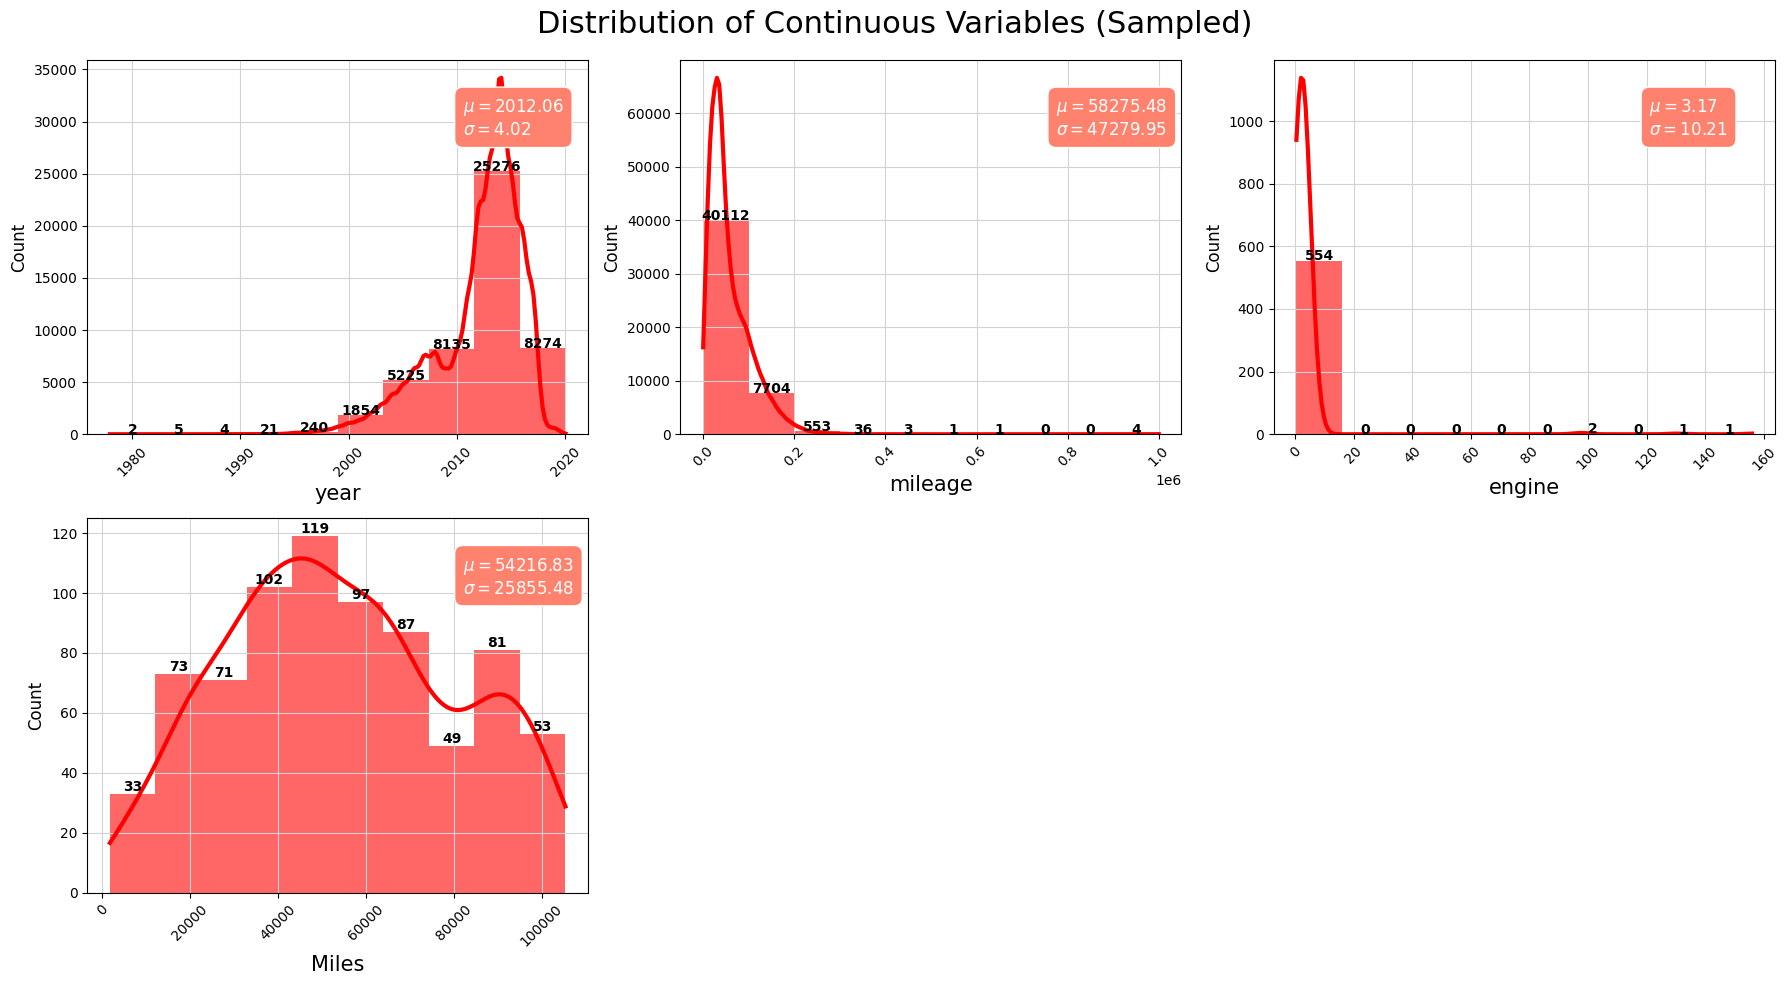

In [15]:
# 1️⃣ Take a small sample for plotting
sample_size = min(100, len(df))  # use 50k or full if smaller
df_sample = df.sample(sample_size, random_state=42)

# 2️⃣ Select only numeric columns (continuous)
df_continuous = df_sample.select_dtypes(include=['float64', 'int64'])

# Drop ID or other numeric-like categorical columns if present
df_continuous = df_continuous.drop(columns=['ID'], errors='ignore')

# 3️⃣ Plotting
num_features = len(df_continuous.columns)
cols = 3
rows = (num_features + cols - 1) // cols

fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(18, 5 * rows))
ax = ax.flatten()

for i, col in enumerate(df_continuous.columns):
    col_data = pd.to_numeric(df_continuous[col], errors='coerce')  # force numeric

    values, bin_edges = np.histogram(col_data.dropna(), bins=10)

    graph = sns.histplot(col_data, bins=bin_edges, kde=True, ax=ax[i],
                         edgecolor='none', color='red', alpha=0.6, line_kws={'lw': 3})
    ax[i].set_xlabel(col, fontsize=15)
    ax[i].set_ylabel('Count', fontsize=12)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].grid(color='lightgrey')

    # Annotate heights
    for p in graph.patches:
        ax[i].annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                       ha='center', fontsize=10, fontweight="bold")

    # Show mean & std
    textstr = '\n'.join((
        r'$\mu=%.2f$' % col_data.mean(),
        r'$\sigma=%.2f$' % col_data.std()
    ))
    ax[i].text(0.75, 0.9, textstr, transform=ax[i].transAxes, fontsize=12, verticalalignment='top',
               color='white', bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

# Turn off unused axes
for j in range(i + 1, len(ax)):
    ax[j].axis('off')

plt.suptitle('Distribution of Continuous Variables (Sampled)', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


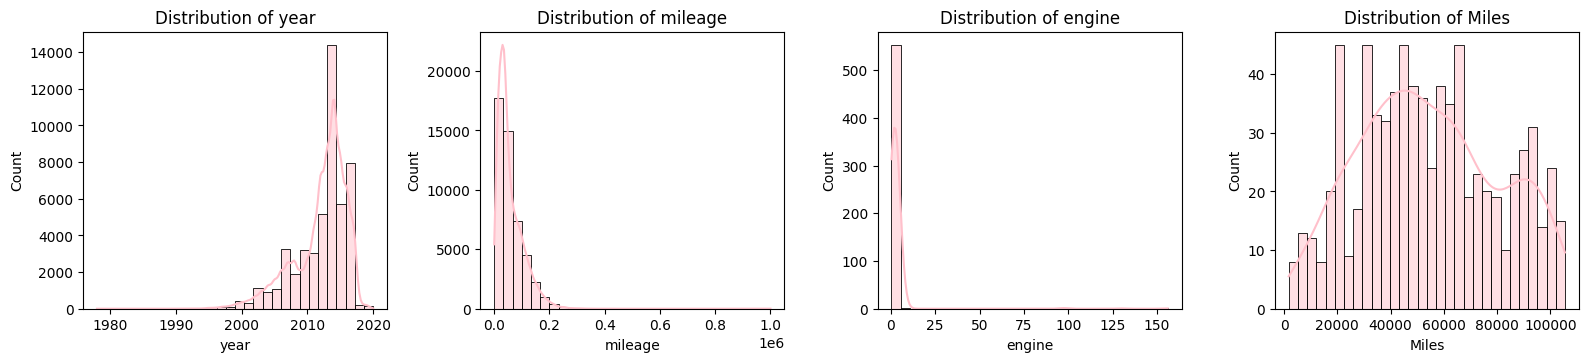

In [16]:
# Numerical columns left after cleaning
numerical_cols = [col for col in ['year', 'mileage', 'engine', 'power', 'seats',
                                  'car_length', 'car_width', 'car_height', 'present_price', 'Miles']
                  if col in df_sample.columns]

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i+1)
    sns.histplot(df_sample[col].dropna(), bins=30, kde=True, color='pink')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


*1.1.2 Categorical Variables*

In [17]:
# Filter out categorical features for the univariate analysis
categorical_features = df.columns.difference(continuous_features)
df_categorical = df[categorical_features]

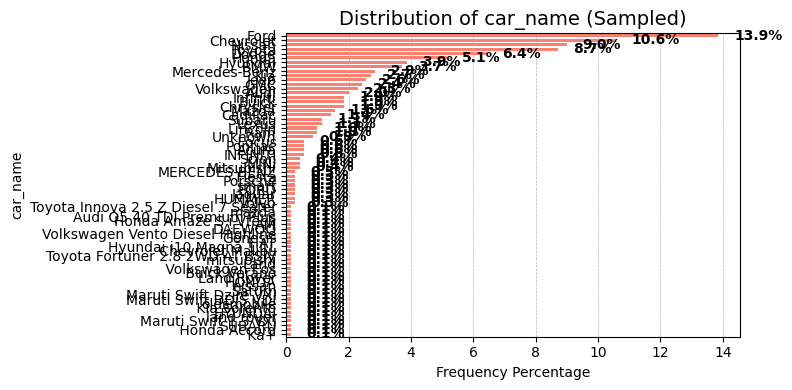

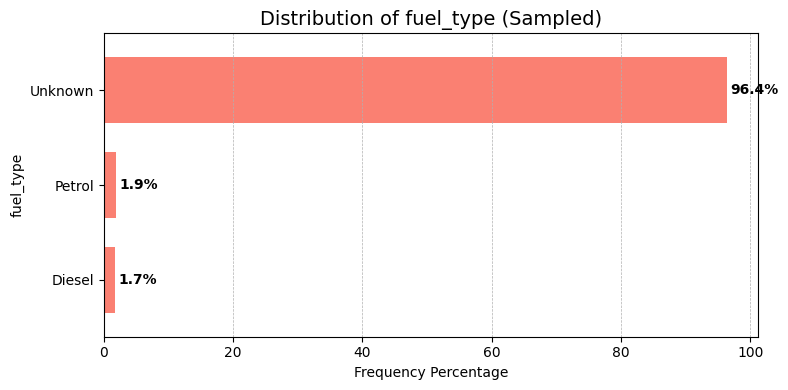

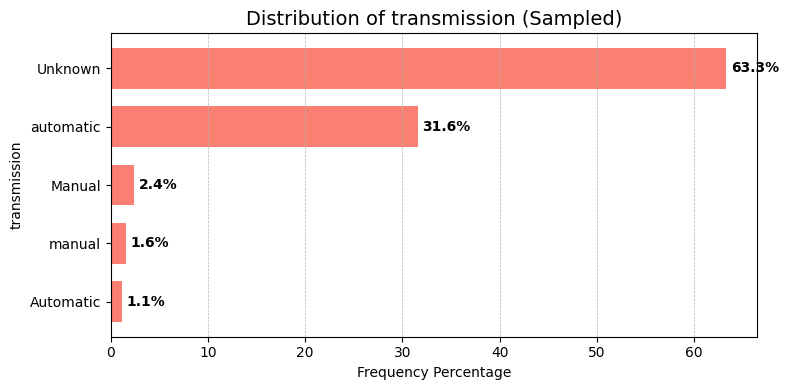

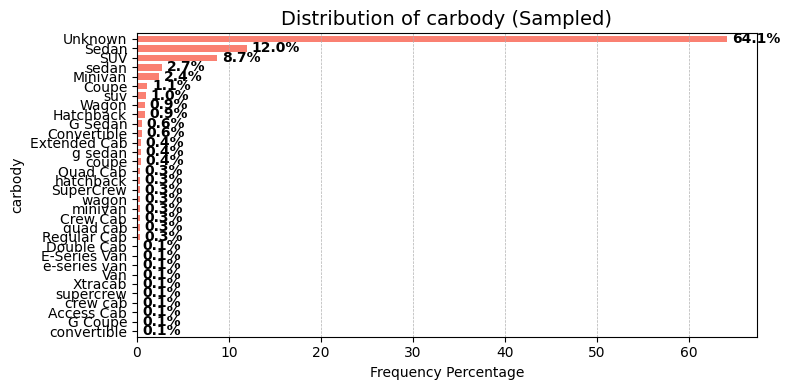

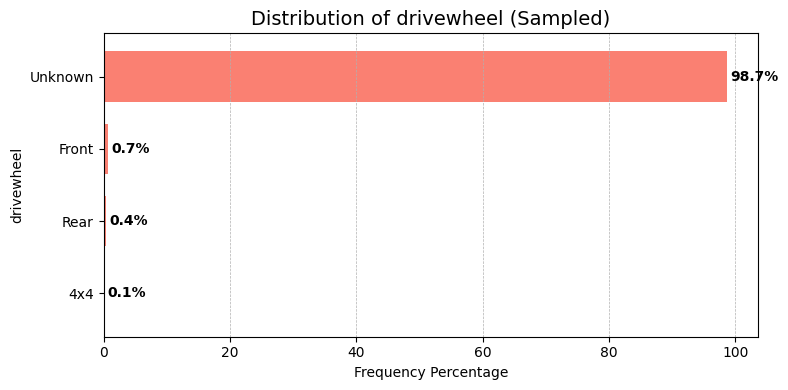

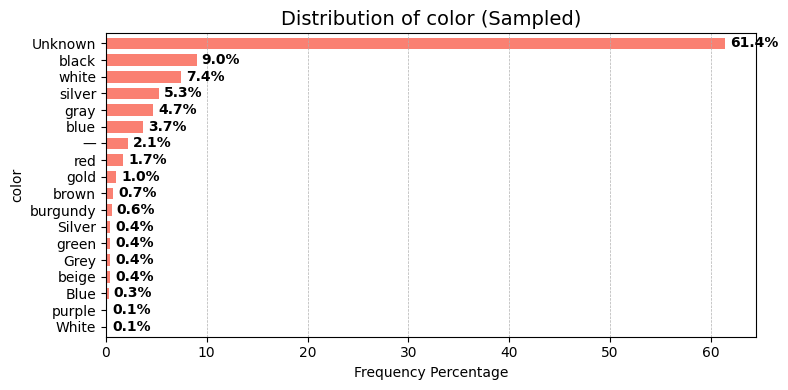

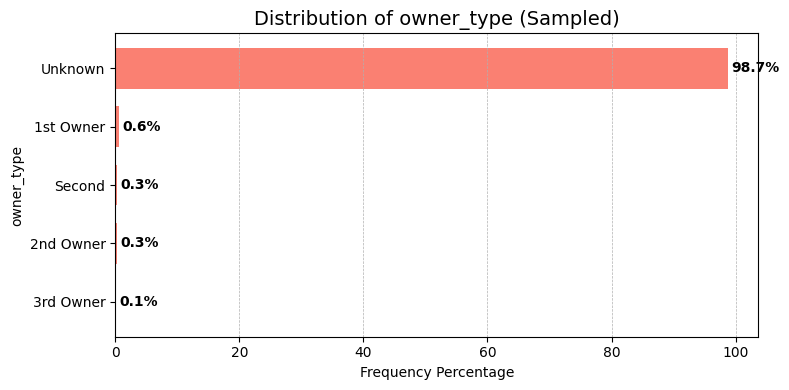

In [18]:
# 1️⃣ Take a small sample for plotting
sample_size = min(100, len(df))  # sample 50k rows or less if dataset is smaller
df_sample = df.sample(sample_size, random_state=42)

# 2️⃣ Define your categorical features (adjust based on your dataset)
categorical_features = [
    'car_name', 'fuel_type', 'transmission', 'carbody',
    'drivewheel', 'color', 'owner_type'
]

# 3️⃣ Plot bar chart for each categorical feature using the sample
import matplotlib.pyplot as plt

for col in categorical_features:
    if col in df_sample.columns:
        plt.figure(figsize=(8, 4))
        value_counts = df_sample[col].value_counts(normalize=True).mul(100).sort_values()

        value_counts.plot(kind='barh', color='salmon', width=0.7)

        # Add percentage labels
        for index, value in enumerate(value_counts):
            plt.text(value + 0.5, index, f'{round(value, 1)}%', va='center', fontsize=10, fontweight='bold')

        plt.title(f'Distribution of {col} (Sampled)', fontsize=14)
        plt.xlabel('Frequency Percentage')
        plt.grid(axis='x', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()


/tmp/ipython-input-4094328006.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_sample[df_sample[col].isin(top_categories)], palette='pastel')
/tmp/ipython-input-4094328006.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_sample[df_sample[col].isin(top_categories)], palette='pastel')
/tmp/ipython-input-4094328006.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_sample[df_sample[col].isin(top_categories)], palette='pastel')
/tmp/ipython-input-4094328006.py:11: FutureWarning: 

Pass

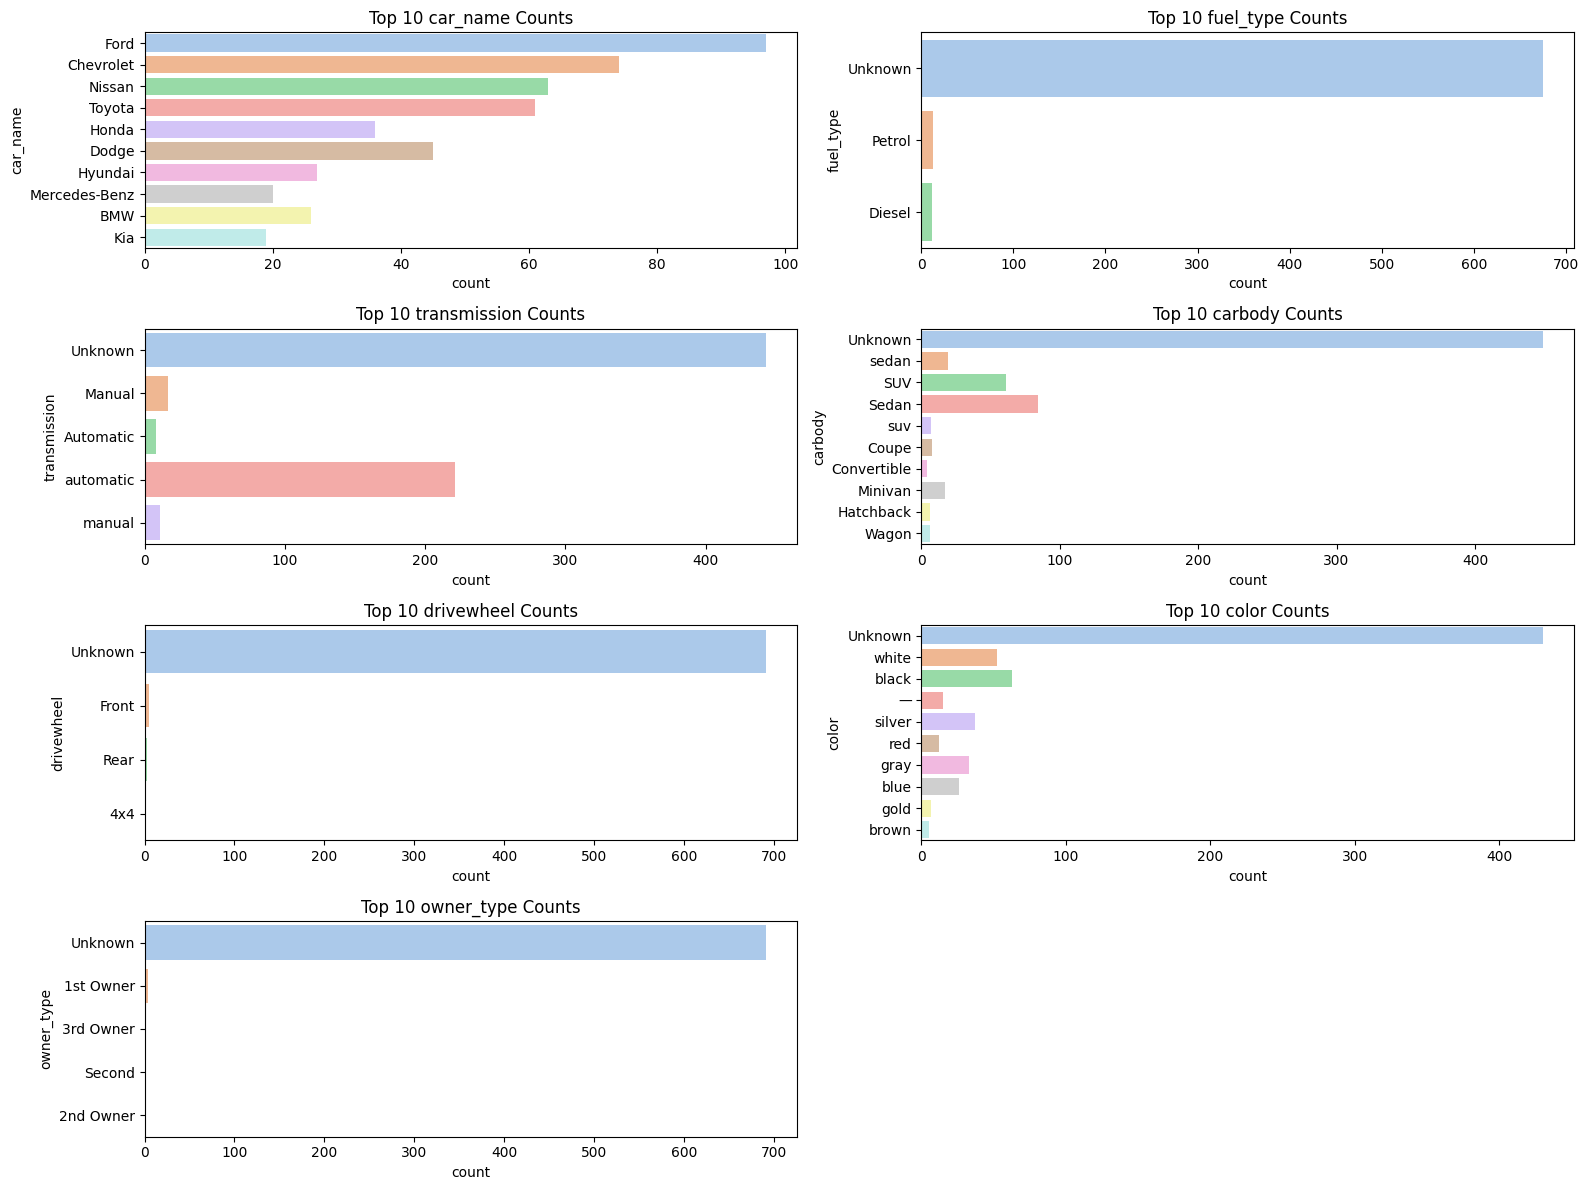

In [19]:
# Categorical columns left after cleaning
categorical_cols = [col for col in ['car_name', 'fuel_type', 'transmission', 'carbody',
                                    'drivewheel', 'color', 'owner_type']
                    if col in df_sample.columns]

plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i+1)
    # Show top 10 categories for better readability
    top_categories = df_sample[col].value_counts().nlargest(10).index
    sns.countplot(y=col, data=df_sample[df_sample[col].isin(top_categories)], palette='pastel')
    plt.title(f'Top 10 {col} Counts')
plt.tight_layout()
plt.show()


## Step 1.2 | Bivariate Analysis
*1.2.1 Numerical Features vs selling_price*

In [20]:
# Clean all continuous features that might have non-numeric characters
for col in continuous_features:
    df[col] = df[col].astype(str)  # Convert to string so .str methods can be used
    df[col] = df[col].str.replace('/', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert back to numeric


In [21]:
non_numeric_cols = [col for col in continuous_features if not pd.api.types.is_numeric_dtype(df[col])]
print("Non-numeric columns:", non_numeric_cols)


Non-numeric columns: []


/tmp/ipython-input-1368714069.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_price = df_sample.groupby('bin')['selling_price'].mean().reset_index()
/tmp/ipython-input-1368714069.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_price = df_sample.groupby('bin')['selling_price'].mean().reset_index()
/tmp/ipython-input-1368714069.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_price = df_sample.

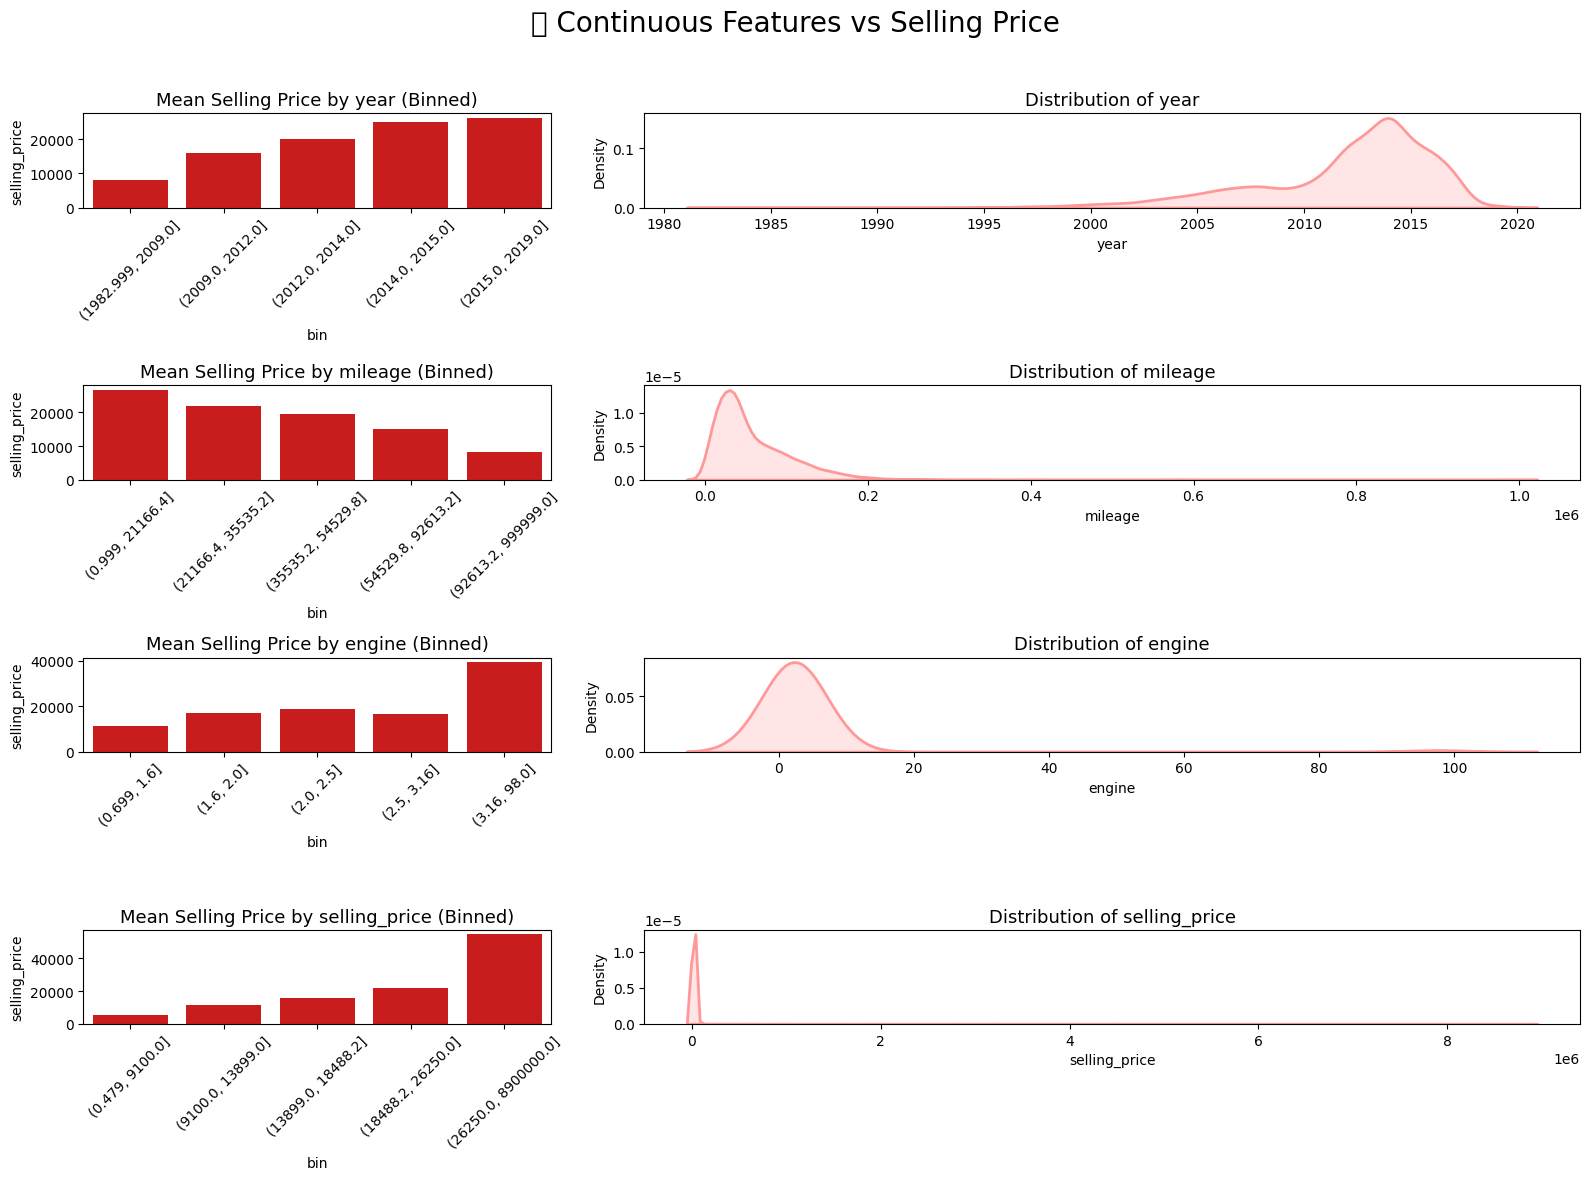

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1️⃣ Take a small sample
sample_size = min(100, len(df))
df_sample = df.sample(sample_size, random_state=42)

# 2️⃣ Ensure selling_price is numeric
df_sample['selling_price'] = pd.to_numeric(df_sample['selling_price'], errors='coerce')

# 3️⃣ Set a clean color palette
sns.set_palette(['#ff9999', '#e60000'])

# 4️⃣ Prepare subplots
fig, ax = plt.subplots(len(continuous_features), 2, figsize=(16, len(continuous_features) * 3),
                       gridspec_kw={'width_ratios': [1, 2]})

# 5️⃣ Iterate through continuous features
for i, col in enumerate(continuous_features):
    if col in df_sample.columns:
        # Barplot: mean selling_price by binned feature (optional: bin continuous feature)
        bins = 5  # number of bins
        df_sample['bin'] = pd.qcut(df_sample[col], q=bins, duplicates='drop')
        mean_price = df_sample.groupby('bin')['selling_price'].mean().reset_index()

        sns.barplot(data=mean_price, x='bin', y='selling_price', ax=ax[i, 0], color='#e60000')
        ax[i, 0].set_title(f'Mean Selling Price by {col} (Binned)', fontsize=13)
        ax[i, 0].tick_params(axis='x', rotation=45)

        # KDE plot: distribution of selling_price by low/high feature (optional)
        sns.kdeplot(data=df_sample, x=col, fill=True, linewidth=2, ax=ax[i, 1])
        ax[i, 1].set_title(f'Distribution of {col}', fontsize=13)

# Remove temporary bin column
df_sample.drop(columns=['bin'], inplace=True)

# Set global figure title
plt.suptitle('📊 Continuous Features vs Selling Price', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


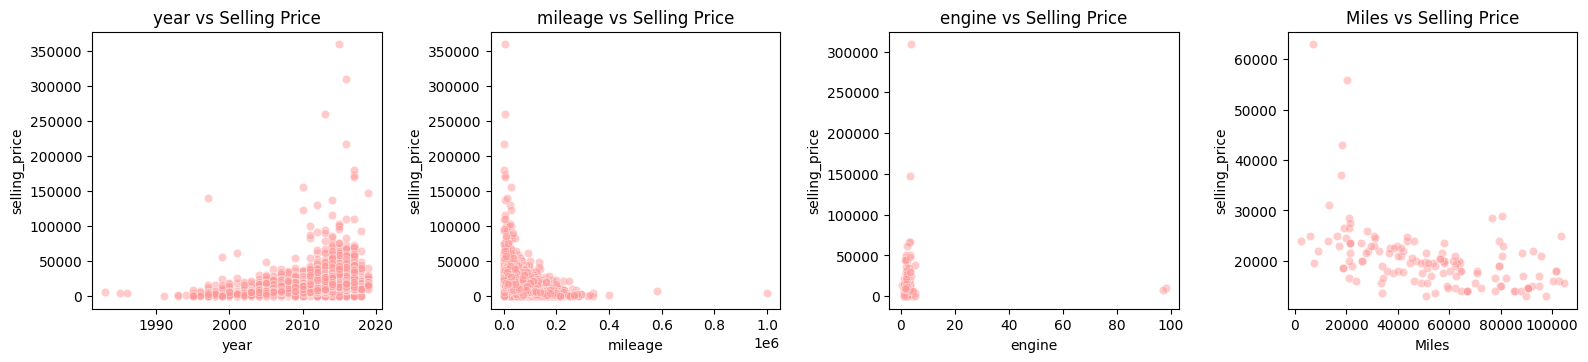

In [23]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i+1)
    sns.scatterplot(data=df_sample, x=col, y='selling_price', alpha=0.5)
    plt.title(f'{col} vs Selling Price')
plt.tight_layout()
plt.show()


*Categorical Features vs selling_price*

In [24]:
# Remove 'selling_price' from the categorical_features
categorical_features = [feature for feature in categorical_features if feature != 'selling_price']

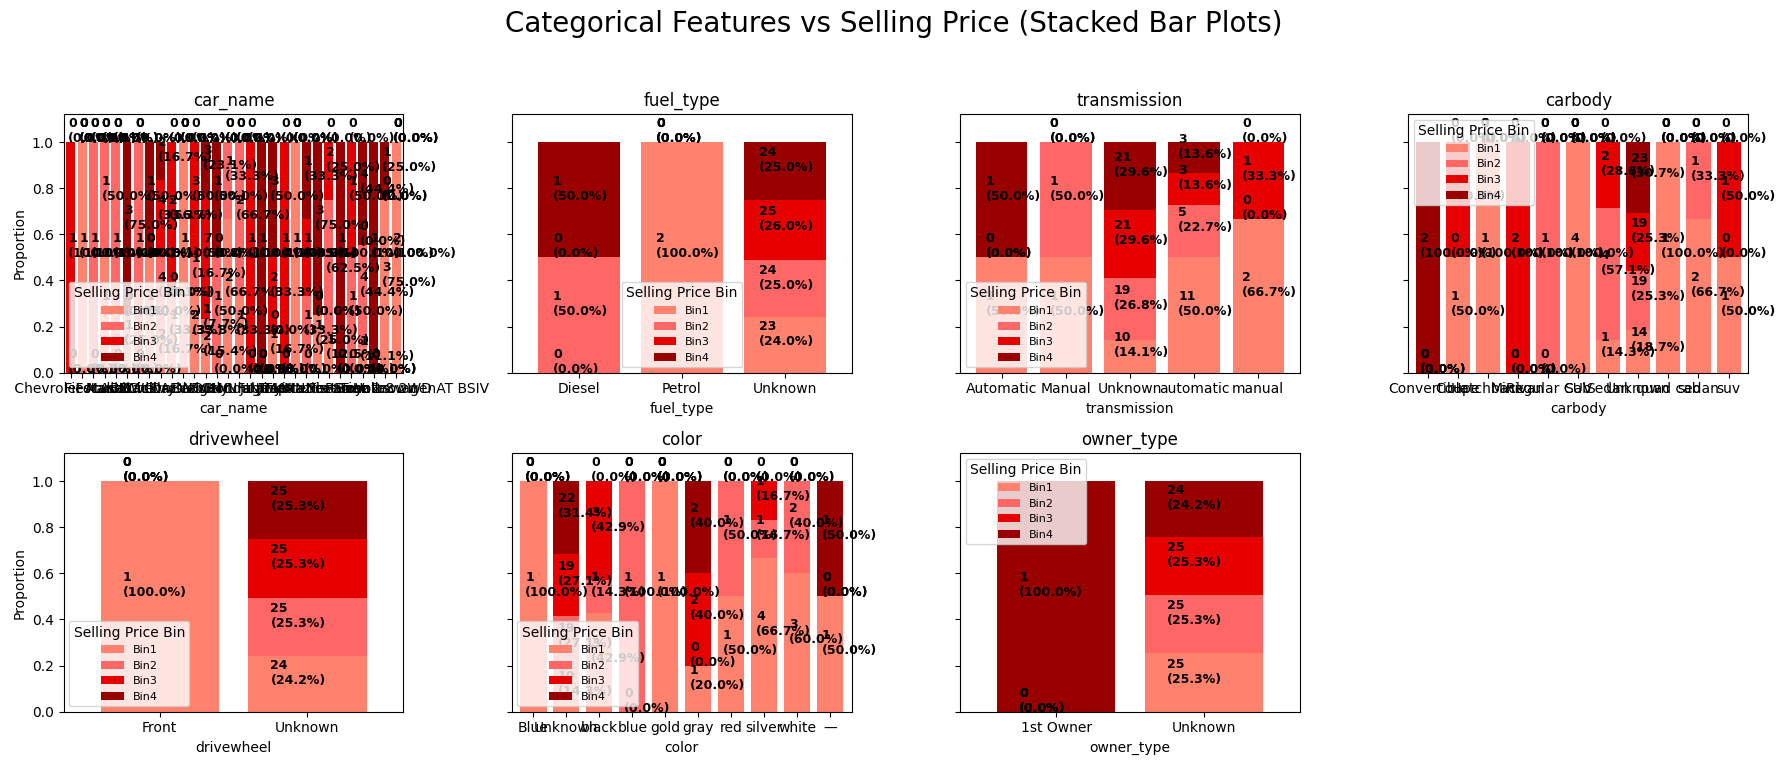

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1️⃣ Sample data for speed
sample_size = min(100, len(df))
df_sample = df.sample(sample_size, random_state=42)

# 2️⃣ Remove target column from features if present
categorical_features = [feature for feature in categorical_features if feature in df_sample.columns]

# 3️⃣ Bin selling_price into categories for stacked plotting
n_bins = 4  # you can change to 3 or 5
df_sample['price_bin'] = pd.qcut(df_sample['selling_price'], q=n_bins, duplicates='drop', labels=[f'Bin{i+1}' for i in range(n_bins)])

# 4️⃣ Prepare subplots
n_features = len(categorical_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))
fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 4 * n_rows))
ax = ax.flatten()

# 5️⃣ Plot stacked bars
for i, col in enumerate(categorical_features):
    cross_tab = pd.crosstab(index=df_sample[col], columns=df_sample['price_bin'])
    cross_tab_prop = cross_tab.div(cross_tab.sum(axis=1), axis=0)

    cmp = ListedColormap(['#ff826e', '#ff6666', '#e60000', '#990000'])

    cross_tab_prop.plot(kind='bar', ax=ax[i], stacked=True, width=0.8, colormap=cmp,
                        legend=False, ylabel='Proportion', sharey=True)

    # Annotate counts & percentages
    for idx, val in enumerate(cross_tab.index.values):
        y_cum = 0
        for j, bin_label in enumerate(cross_tab.columns):
            proportion = cross_tab_prop.loc[val, bin_label]
            count = cross_tab.loc[val, bin_label]
            ax[i].text(x=idx-0.25, y=y_cum + proportion/2,
                       s=f'{count}\n({np.round(proportion*100,1)}%)',
                       color='black', fontsize=9, fontweight='bold')
            y_cum += proportion

    ax[i].legend(title='Selling Price Bin', loc='best', fontsize=8)
    ax[i].set_ylim([0, 1.12])
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=0)
    ax[i].set_title(f'{col}', fontsize=12)

# Hide any unused subplots
for j in range(i+1, len(ax)):
    fig.delaxes(ax[j])

plt.suptitle('Categorical Features vs Selling Price (Stacked Bar Plots)', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Remove temporary price_bin column
df_sample.drop(columns=['price_bin'], inplace=True)


/tmp/ipython-input-1315153003.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample[df_sample[col].isin(top_categories)], x=col, y='selling_price', palette='Set3')
/tmp/ipython-input-1315153003.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample[df_sample[col].isin(top_categories)], x=col, y='selling_price', palette='Set3')
/tmp/ipython-input-1315153003.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample[df_sample[col].isin(top_categories)], x=col, y='selling_price', palette='Set3')
/tmp/ipython-inp

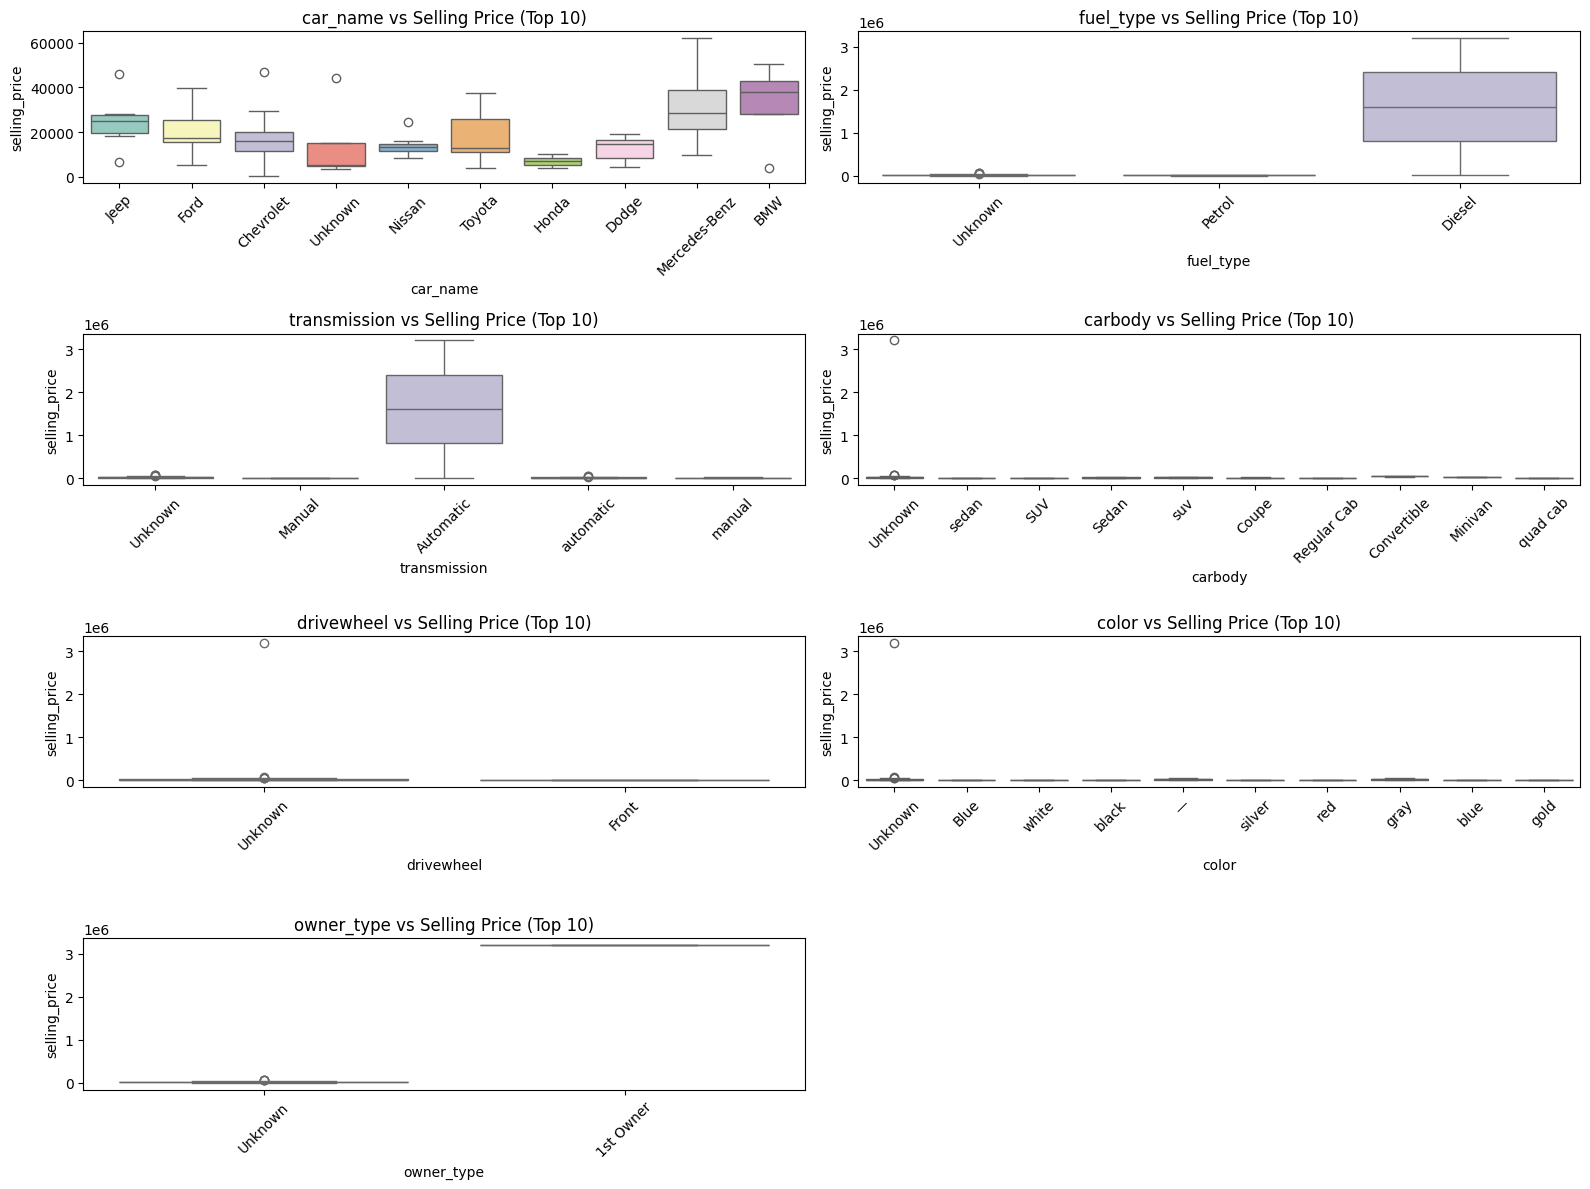

In [26]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i+1)
    # Top 10 categories only
    top_categories = df_sample[col].value_counts().nlargest(10).index
    sns.boxplot(data=df_sample[df_sample[col].isin(top_categories)], x=col, y='selling_price', palette='Set3')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Selling Price (Top 10)')
plt.tight_layout()
plt.show()


# **Step 2 | Data Preprocessing**

#Step 2.1 Irrelevant Features Removal


In [27]:
irrelevant_cols = ['ID', 'present_price', 'car_length', 'car_width', 'car_height', 'Miles']
df_sample = df_sample.drop(columns=[col for col in irrelevant_cols if col in df_sample.columns])


#Step 2.2 Missing Value Treatment


In [28]:
# Check for missing values in the dataset
df.isnull().sum().sum()

np.int64(3000410)

In [29]:
missing = df_sample.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df_sample) * 100).round(2)
pd.DataFrame({'Missing Values': missing, '% of total': missing_percent})


,Missing Values,% of total
engine,99,99.0
mileage,3,3.0
year,2,2.0
car_name,0,0.0
fuel_type,0,0.0
transmission,0,0.0
carbody,0,0.0
drivewheel,0,0.0
color,0,0.0
selling_price,0,0.0


In [30]:
# Drop columns with >90% missing
df.drop(columns=['engine', 'Miles'], inplace=True)

# Impute small missing numeric columns
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['mileage'].fillna(df['mileage'].median(), inplace=True)

df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['year'].fillna(df['year'].median(), inplace=True)


/tmp/ipython-input-40959303.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mileage'].fillna(df['mileage'].median(), inplace=True)
/tmp/ipython-input-40959303.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [31]:
df.isnull().sum().sum()


np.int64(0)

#Step 2.3 Outlier Treatment


In [32]:
continuous_features

['year', 'mileage', 'engine', 'selling_price']

In [33]:
# Filter continuous_features to existing columns
continuous_features_present = [col for col in continuous_features if col in df.columns]

# Compute IQR and detect outliers
Q1 = df[continuous_features_present].quantile(0.25)
Q3 = df[continuous_features_present].quantile(0.75)
IQR = Q3 - Q1

outliers_count_specified = ((df[continuous_features_present] < (Q1 - 1.5 * IQR)) |
                            (df[continuous_features_present] > (Q3 + 1.5 * IQR))).sum()

print("Outliers per continuous feature:")
print(outliers_count_specified)


Outliers per continuous feature:
year             88913
mileage          53596
selling_price    55763
dtype: int64


#Step 2.4 Categorical Features Encoding


In [136]:
print(X_train.columns.tolist())


['year', 'mileage', 'car_name_ Acura MDX', 'car_name_ Acura RDX', 'car_name_ Acura RLX', 'car_name_ Acura TSX', 'car_name_ Alfa Romeo Giulia', 'car_name_ Audi A', 'car_name_ Audi Q', 'car_name_ Audi S', 'car_name_ B-MAX', 'car_name_ BMW  Series', 'car_name_ BMW X', 'car_name_ BMW i', 'car_name_ Buick Encore', 'car_name_ Buick Encore GX', 'car_name_ Buick Envision', 'car_name_ Buick LaCrosse', 'car_name_ Buick Regal', 'car_name_ Buick Verano', 'car_name_ C-MAX', 'car_name_ Cadillac ATS', 'car_name_ Cadillac DTS', 'car_name_ Cadillac XT', 'car_name_ Chevrolet Blazer', 'car_name_ Chevrolet Camaro', 'car_name_ Chevrolet Captiva Sport', 'car_name_ Chevrolet Colorado Crew Cab', 'car_name_ Chevrolet Corvette', 'car_name_ Chevrolet Cruze', 'car_name_ Chevrolet Cruze Limited', 'car_name_ Chevrolet Equinox', 'car_name_ Chevrolet Impala', 'car_name_ Chevrolet Malibu', 'car_name_ Chevrolet Silverado  Double Cab', 'car_name_ Chevrolet Silverado  HD Crew Cab', 'car_name_ Chevrolet Spark', 'car_name_

In [138]:
# 1️⃣ Take a small sample
sample_size = min(50000, len(df))
df_sample = df.sample(sample_size, random_state=42)

# 2️⃣ Drop 'ID' since it's not useful for modeling
df_sample = df_sample.drop(columns=['ID'], errors='ignore')

# 3️⃣ Define categorical columns for one-hot encoding
categorical_cols = [
    'car_name', 'fuel_type', 'transmission', 'carbody',
    'drivewheel', 'color', 'owner_type'
]

# Only keep columns that exist in the sample
categorical_cols = [col for col in categorical_cols if col in df_sample.columns]

# 4️⃣ One-hot encode categorical features
df_encoded = pd.get_dummies(df_sample, columns=categorical_cols, drop_first=True)

# 5️⃣ Convert remaining numeric features to integers if needed
# Adjust according to your dataset
numeric_cols_to_int = ['year', 'mileage', 'seats', 'power']  # optional
numeric_cols_to_int = [col for col in numeric_cols_to_int if col in df_encoded.columns]

for col in numeric_cols_to_int:
    df_encoded[col] = df_encoded[col].astype(int)

# 6️⃣ Check resulting data types
df_encoded.dtypes


,0
year,int64
mileage,int64
selling_price,float64
car_name_ Acura MDX,bool
car_name_ Acura RDX,bool
...,...
owner_type_4th Owner,bool
owner_type_First,bool
owner_type_Second,bool
owner_type_Third,bool


In [35]:
# Displaying the resulting DataFrame after one-hot encoding
df_encoded.head()

,year,mileage,selling_price,car_name_ Acura MDX,car_name_ Acura RDX,car_name_ Acura RLX,car_name_ Acura TSX,car_name_ Alfa Romeo Giulia,car_name_ Audi A,car_name_ Audi Q,...,color_yellow,color_—,owner_type_1st Owner,owner_type_2nd Owner,owner_type_3rd Owner,owner_type_4th Owner,owner_type_First,owner_type_Second,owner_type_Third,owner_type_Unknown
1089076,2015,41275,27999.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1168122,2014,19962,14480.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
834951,2013,86739,5995.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
868677,2012,68425,16900.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
577801,2017,12289,8899.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


#Step 2.5 Transforming Skewed Features

In [36]:
# Define features (X) and target variable (y)
# Ensure 'selling_price' exists in df_encoded
X = df_encoded.drop('selling_price', axis=1, errors='ignore')
y = df_encoded['selling_price']

# Optional: check shapes
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (50000, 792)
Target shape: (50000,)


In [37]:
from sklearn.model_selection import train_test_split

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0  # no stratify for continuous target
)

# Optional: check shapes
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


X_train: (40000, 792), X_test: (10000, 792)
y_train: (40000,), y_test: (10000,)


In [38]:
continuous_features = ['year', 'mileage']   # exclude target column


In [39]:
# Define continuous features present in dataset
continuous_features = [col for col in ['year', 'mileage', 'selling_price'] if col in X_train.columns]

# Add a small constant to avoid zeros or negatives
for col in continuous_features:
    X_train[col] = X_train[col] + 0.001
    X_test[col] = X_test[col] + 0.001


In [40]:
# Clean continuous features before transformation
for col in continuous_features:
    # Replace inf with NaN
    X_train[col].replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test[col].replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill NaN with median (robust choice for skewed data)
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)


/tmp/ipython-input-2355611268.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-2355611268.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

/usr/local/lib/python3.12/dist-packages/scipy/stats/_morestats.py:1186: UserWarning: The optimal lambda is 249.84071000119476, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in float64.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


⚠️ Skipped year due to error: array must not contain infs or NaNs


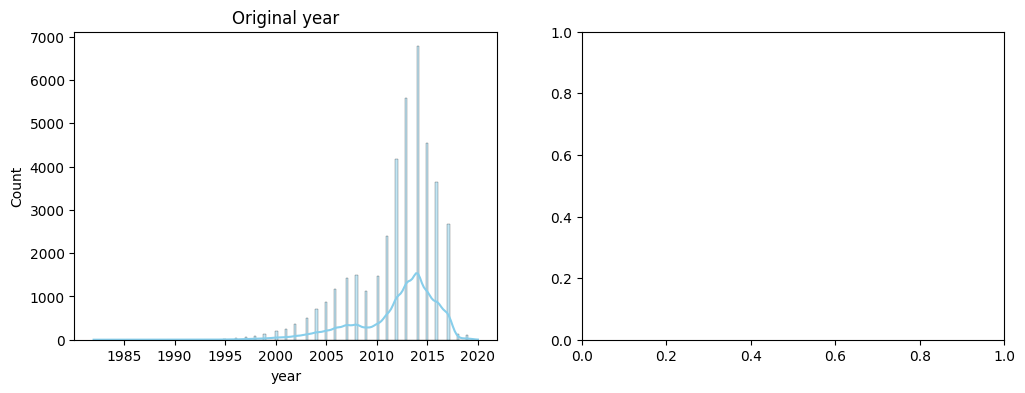

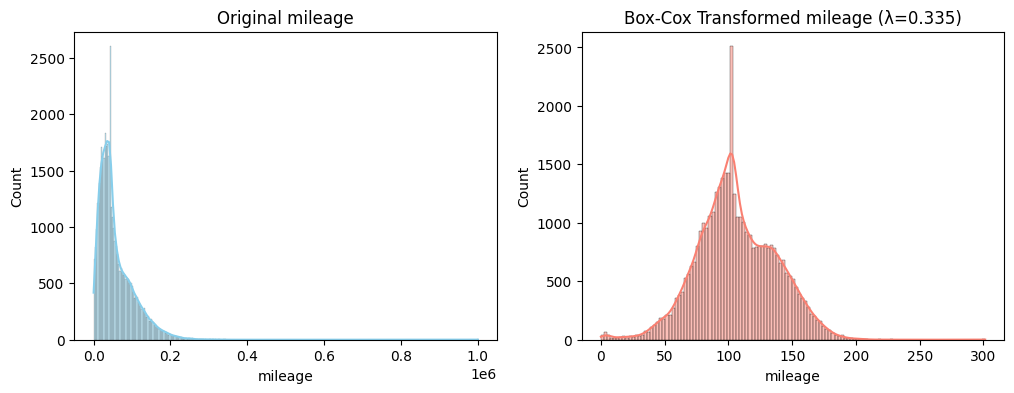

Box-Cox lambdas: {'year': np.float64(92.6441638060196), 'mileage': np.float64(0.33465765729362457)}


In [41]:
from scipy.stats import boxcox
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ✅ Continuous features from your dataset
continuous_features = ['year', 'mileage']

# Dictionary to store lambda values
lambdas = {}

# Work on copies to avoid in-place errors
X_train_bc = X_train.copy()
X_test_bc = X_test.copy()

for col in continuous_features:
    plt.figure(figsize=(12, 4))

    # ✅ Shift if non-positive values exist
    if (X_train_bc[col] <= 0).any():
        shift_val = abs(X_train_bc[col].min()) + 1e-3
        X_train_bc[col] = X_train_bc[col] + shift_val
        X_test_bc[col] = X_test_bc[col] + shift_val

    # ✅ Clip extreme values to avoid overflow in Box-Cox
    X_train_bc[col] = np.clip(X_train_bc[col], 1e-3, 1e10)

    # Original distribution
    plt.subplot(1, 2, 1)
    sns.histplot(X_train_bc[col], kde=True, color='skyblue')
    plt.title(f'Original {col}')

    try:
        # ✅ Apply Box-Cox safely
        transformed, lam = boxcox(X_train_bc[col])
        lambdas[col] = lam

        # Store back transformed values
        X_train_bc[col] = transformed

        # Transform test set using same lambda
        X_test_bc[col] = boxcox(X_test_bc[col], lmbda=lam)

        # Transformed distribution
        plt.subplot(1, 2, 2)
        sns.histplot(X_train_bc[col], kde=True, color='salmon')
        plt.title(f'Box-Cox Transformed {col} (λ={lam:.3f})')

    except ValueError as e:
        print(f"⚠️ Skipped {col} due to error: {e}")

    plt.show()

print("Box-Cox lambdas:", lambdas)


In [42]:
X_train.head()

,year,mileage,car_name_ Acura MDX,car_name_ Acura RDX,car_name_ Acura RLX,car_name_ Acura TSX,car_name_ Alfa Romeo Giulia,car_name_ Audi A,car_name_ Audi Q,car_name_ Audi S,...,color_yellow,color_—,owner_type_1st Owner,owner_type_2nd Owner,owner_type_3rd Owner,owner_type_4th Owner,owner_type_First,owner_type_Second,owner_type_Third,owner_type_Unknown
674773,2017.001,24639.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
136203,2007.001,193588.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
755958,2017.001,29441.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
320982,2014.001,16020.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1284257,2006.001,122934.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [43]:
# Fix selling_price separately
y_train = y_train.replace([np.inf, -np.inf], np.nan)
y_test = y_test.replace([np.inf, -np.inf], np.nan)

y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_train.median())

# Apply Box-Cox on y_train
try:
    y_train_transformed, lam_y = boxcox(y_train + 0.001)  # ensure positive
    print(f"Box-Cox λ for selling_price = {lam_y:.2f}")
except Exception as e:
    print(f"⚠️ Could not apply Box-Cox on selling_price: {e}")


Box-Cox λ for selling_price = 0.18


In [44]:
X_train.head()

,year,mileage,car_name_ Acura MDX,car_name_ Acura RDX,car_name_ Acura RLX,car_name_ Acura TSX,car_name_ Alfa Romeo Giulia,car_name_ Audi A,car_name_ Audi Q,car_name_ Audi S,...,color_yellow,color_—,owner_type_1st Owner,owner_type_2nd Owner,owner_type_3rd Owner,owner_type_4th Owner,owner_type_First,owner_type_Second,owner_type_Third,owner_type_Unknown
674773,2017.001,24639.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
136203,2007.001,193588.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
755958,2017.001,29441.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
320982,2014.001,16020.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1284257,2006.001,122934.001,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


# *Step 3 Decision Tree Model Building*


##Step 3.1 DT Base Model Definition


In [45]:
from sklearn.tree import DecisionTreeClassifier


In [46]:
# Define the base DT model
dt_base = DecisionTreeClassifier(random_state=0)

##Step 6.2 DT Hyperparameter Tuning



In [47]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# 1. Take a small sample
# -----------------------------
sample_df = df.sample(n=100, random_state=42).copy()  # adjust n if dataset smaller

# -----------------------------
# 2. Handle missing / inf values
# -----------------------------
sample_df = sample_df.replace([np.inf, -np.inf], np.nan)  # replace inf with NaN
sample_df = sample_df.dropna()  # drop rows with NaN for now (later we can impute)

# -----------------------------
# 3. Encode categorical columns
# -----------------------------
label_encoders = {}
for col in sample_df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    sample_df[col] = le.fit_transform(sample_df[col].astype(str))
    label_encoders[col] = le

# -----------------------------
# 4. Split features/target
# -----------------------------
X = sample_df.drop(columns=['selling_price'])
y = sample_df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 5. Define model + param grid
# -----------------------------
dt_reg = DecisionTreeRegressor(random_state=0)

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

# -----------------------------
# 6. Grid Search
# -----------------------------
cv = KFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    dt_reg,
    param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    error_score='raise'  # force raise if error
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best R2:", grid_search.best_score_)


Best params: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best R2: -10.42129017228631


In [48]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):
    '''
    This function optimizes the hyperparameters for a classifier by searching over a specified hyperparameter grid.
    It uses GridSearchCV and cross-validation (StratifiedKFold) to evaluate different combinations of hyperparameters.
    The combination with the highest recall for class 1 is selected as the default scoring metric.
    The function returns the classifier with the optimal hyperparameters.
    '''

    # Create the cross-validation object using StratifiedKFold to ensure the class distribution is the same across all the folds
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    # Create the GridSearchCV object
    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)

    # Fit the GridSearchCV object to the training data
    clf_grid.fit(X_train, y_train)

    # Get the best hyperparameters
    best_hyperparameters = clf_grid.best_params_

    # Return best_estimator_ attribute which gives us the best model that has been fitted to the training data
    return clf_grid.best_estimator_, best_hyperparameters

In [49]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
print(categorical_cols)


[]


In [50]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure both train and test have same columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


In [51]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold


In [52]:
def tune_regressor_hyperparameters(reg, param_grid, X_train, y_train, scoring='r2', n_splits=3):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    grid = GridSearchCV(reg, param_grid, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_


In [53]:
dt_base = DecisionTreeRegressor(random_state=0)

param_grid_dt = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [54]:
best_dt, best_dt_hyperparams = tune_regressor_hyperparameters(dt_base, param_grid_dt, X_train, y_train)

print("Best hyperparameters:", best_dt_hyperparams)


Best hyperparameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


##Step 6.3 DT Model Evaluation Model

In [57]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Compute RMSE manually
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print("Decision Tree RMSE:", rmse_dt)


Decision Tree RMSE: 15296.929663334407


 # **Step 7 Random Forest Model Building**

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 7.1 | RF Base Model
rf_base = RandomForestRegressor(random_state=0)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

# 7.3 | RF Model Evaluation
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)


Random Forest R2: -1.6132062594364225
Random Forest RMSE: 36750.84223833446


In [61]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 8.1 | KNN Base Model Definition
knn_base = KNeighborsRegressor()
knn_base.fit(X_train, y_train)
y_pred_knn = knn_base.predict(X_test)

# 8.3 | KNN Model Evaluation
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("KNN R2:", r2_knn)
print("KNN RMSE:", rmse_knn)

# 8.2 | KNN Hyperparameter Tuning (optional)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid_knn = GridSearchCV(knn_base, param_grid_knn, cv=3, scoring='r2', n_jobs=-1)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)

r2_best_knn = r2_score(y_test, y_pred_best_knn)
rmse_best_knn = np.sqrt(mean_squared_error(y_test, y_pred_best_knn))

print("Best KNN Hyperparameters:", grid_knn.best_params_)
print("Best KNN R2:", r2_best_knn)
print("Best KNN RMSE:", rmse_best_knn)


KNN R2: -20.50117467083244
KNN RMSE: 105417.21664490674
Best KNN Hyperparameters: {'n_neighbors': 10, 'p': 2, 'weights': 'uniform'}
Best KNN R2: -6.845420105256455
Best KNN RMSE: 63677.87375956064


In [73]:
# Step 9 | SVM Model Building

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Take a small sample to speed things up
df_sample = df_encoded.sample(n=200, random_state=0)  # adjust n as needed

# Define features and target
X = df_sample.drop('selling_price', axis=1, errors='ignore')
y = df_sample['selling_price']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Step 9.1 | SVM Base Model Definition
svm_base = SVR()

# Step 9.2 | SVM Hyperparameter Tuning (simple grid to save time)
param_grid_svm = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(svm_base, param_grid_svm, cv=3, scoring='r2', n_jobs=-1)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_
print("Best SVM Parameters:", svm_grid.best_params_)

# Step 9.3 | SVM Model Evaluation
y_pred_svm = best_svm.predict(X_test)
print("SVM R2:", r2_score(y_test, y_pred_svm))
from sklearn.metrics import mean_squared_error
import numpy as np

# Predictions
y_pred_svm = best_svm.predict(X_test)

# Calculate RMSE manually
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))

# Print metrics
print("SVM R2:", r2_score(y_test, y_pred_svm))
print("SVM RMSE:", rmse_svm)



Best SVM Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
SVM R2: 0.3086986866727608
SVM R2: 0.3086986866727608
SVM RMSE: 9608.177240913603


In [78]:
import joblib
joblib.dump(best_svm, 'svm_car_price_model.pkl')


['svm_car_price_model.pkl']

In [80]:
import joblib

# Save encoders
for col, le in label_encoders.items():
    joblib.dump(le, f"{col}_encoder.pkl")

# Later: Load encoder
le = joblib.load("fuel_type_encoder.pkl")
encoded_col = le.transform(["Petrol"])


In [81]:
joblib.dump(best_dt, "decision_tree_model.pkl")


['decision_tree_model.pkl']

In [115]:
import joblib

# Assuming 'scaler' is your trained scaler object
joblib.dump(scaler, "scaler.pkl")
print("✅ Scaler saved as scaler.pkl")


✅ Scaler saved as scaler.pkl


In [85]:
feature_columns = ['year', 'mileage', 'engine', 'power', 'fuel_type', 'car_name', ...]  # all columns in order
joblib.dump(feature_columns, "feature_columns.pkl")


['feature_columns.pkl']

In [137]:
import joblib
import pandas as pd

# Save after preprocessing
joblib.dump(X_train.columns, "model_columns.pkl")


['model_columns.pkl']

In [88]:
def safe_encode(encoder, value):
    try:
        return encoder.transform([value])[0]
    except ValueError:
        # If unseen, map to a default or most frequent category
        return encoder.transform([encoder.classes_[0]])[0]  # first class as fallback

for col in categorical_cols:
    user_input[col] = safe_encode(globals()[f"{col}_encoder"], user_input[col])


In [94]:
import joblib

# Load encoders explicitly
car_name_encoder = joblib.load("car_name_encoder.pkl")
fuel_type_encoder = joblib.load("fuel_type_encoder.pkl")
carbody_encoder = joblib.load("carbody_encoder.pkl")
color_encoder = joblib.load("color_encoder.pkl")
drivewheel_encoder = joblib.load("drivewheel_encoder.pkl")
owner_type_encoder = joblib.load("owner_type_encoder.pkl")
transmission_encoder = joblib.load("transmission_encoder.pkl")

categorical_cols = ['car_name','fuel_type','carbody','color','drivewheel','owner_type','transmission']

def safe_encode(encoder, value):
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    else:
        # Map unseen category to the most frequent category
        return encoder.transform([encoder.classes_[0]])[0]

# Example user input dictionary
user_input = {
    'car_name': 'Maruti Swift',  # unseen example
    'fuel_type': 'Petrol',
    'carbody': 'Hatchback',
    'color': 'Red',
    'drivewheel': 'FWD',
    'owner_type': 'First Owner',
    'transmission': 'Manual',
    'year': 2018,
    'mileage': 18,
    'engine': 1200,
    'max_power': 82,
    'torque': 114,
    'seats': 5
}

# Encode categorical features safely
for col in categorical_cols:
    user_input[col] = safe_encode(globals()[f"{col}_encoder"], user_input[col])

# Convert to DataFrame
import pandas as pd
X_input = pd.DataFrame([user_input])


In [96]:
# Load model and columns
svm_model = joblib.load("svm_car_price_model.pkl")
model_columns = joblib.load("model_columns.pkl")

# User input DataFrame (after safe encoding)
X_input = pd.DataFrame([user_input])

# One-hot encode manually (pd.get_dummies) or use saved encoders
X_input = pd.get_dummies(X_input)

# Reindex to match training columns
X_input = X_input.reindex(columns=model_columns, fill_value=0)

predicted_price = svm_model.predict(X_input)[0]
print("Predicted Price:", predicted_price)


Predicted Price: 20719.1292820793


In [116]:
import joblib
scaler = joblib.load("scaler.pkl")
print(hasattr(scaler, "mean_"))  # Should be True if fitted


True


In [117]:
# List numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(numeric_cols)


['ID', 'year', 'mileage', 'selling_price']


In [127]:
from sklearn.preprocessing import StandardScaler
import joblib

numerical_cols = ['year', 'mileage']

scaler = StandardScaler()
scaler.fit(df[numerical_cols])  # df is your training DataFrame
joblib.dump(scaler, "scaler.pkl")  # Save the fitted scaler


['scaler.pkl']

In [142]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# Load scaler and model_columns
scaler = joblib.load("scaler.pkl")
model_columns = joblib.load("model_columns.pkl")

# Example input
user_input = {
    "year": [2018],
    "mileage": [25000],
    "car_name": ["Honda Civic"],
    "carbody": ["Sedan"],
    "color": ["Blue"],
    "drivewheel": ["FWD"],
    "owner_type": ["1st Owner"],
    "transmission": ["Manual"],
    "fuel_type": ["Petrol"]
}

X_input = pd.DataFrame(user_input)

# Scale numerical columns
numerical_cols = ['year', 'mileage']
# Ensure numerical columns exist in input before scaling
numerical_cols_present = [col for col in numerical_cols if col in X_input.columns]
if numerical_cols_present:
    X_input[numerical_cols_present] = scaler.transform(X_input[numerical_cols_present])

# One-hot encode categorical columns
# Use pd.get_dummies on the input
X_input_encoded = pd.get_dummies(X_input)

# Ensure the columns match the training data columns using reindex
# This is the crucial step to align the input data with the model's expected features.
X_input_encoded = X_input_encoded.reindex(columns=model_columns, fill_value=0)

# Optional: Verify columns
# print("Input columns after reindexing:", X_input_encoded.columns.tolist())
# print("Model columns:", model_columns.tolist())

In [143]:
model = joblib.load("svm_car_price_model.pkl")
# Use the correctly prepared X_input_encoded DataFrame
pred = model.predict(X_input_encoded)
# Remove predict_proba as SVM Regressor does not have this method
print(pred)

[-9273.81795339]
